
<center>
<img src="https://github.com/HoTruongAnBBA2024/Investments_WS2026/blob/main/images/fscampus_small2.png?raw=1" width="1200"/>
</center>

<center>

# Investments

***Finance 2 - BFIN***

**Dr. Omer Cayirli**

Lecturer in Empirical Finance

omer_cayirli@uncbusiness.net
</center>

---

## Lecture 03
---

### Outline
*   Fixed-Income Securities II
    *   Managing Bond Portfolios
        *   Interest rate risk
            *   Interest rate sensitivity of bond prices
            *   Duration and its determinants
            *   Convexity
        *   Passive and active management strategies

---



### Interest Rate Risk
*   Bond prices and yields move in opposite directions.

*   For equal changes in yield, a decrease produces a larger price gain than the loss caused by an increase.

*   Longer maturities and lower coupon rates increase price sensitivity.

Assume a USD 1,000 face value, semiannual compounding, and a 6% initial yield to maturity (APR). The coupon bond pays USD 30 every six months.

#### 6% Coupon Bond

| YTM (APR) | $T = 1$ | $T = 10$ | $T = 20$ |
|:---|---:|---:|---:|
| 5% | 1,009.64 | 1,077.95 | 1,125.51 |
| 6% (initial) | 1,000.00 | 1,000.00 | 1,000.00 |
| 7% | 990.50 | 928.94 | 893.22 |
| Price change: 6% to 5% | +0.96% | +7.79% | +12.55% |
| Price change: 6% to 7% | -0.95% | -7.11% | -10.68% |

#### Zero-Coupon Bond

| YTM (APR) | $T = 1$ | $T = 10$ | $T = 20$ |
|:---|---:|---:|---:|
| 5% | 951.81 | 610.27 | 372.43 |
| 6% (initial) | 942.60 | 553.68 | 306.56 |
| 7% | 933.51 | 502.57 | 252.57 |
| Price change: 6% to 5% | +0.98% | +10.22% | +21.49% |
| Price change: 6% to 7% | -0.96% | -9.23% | -17.61% |

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# --- 1. Core Calculation Function ---
def calculate_bond_price(face_value, coupon_rate, ytm, years):
    coupon_payment = face_value * coupon_rate
    if ytm <= 0: return np.nan
    price = coupon_payment * ((1 - (1 + ytm)**-years) / ytm) + face_value / (1 + ytm)**years
    return price

# --- 2. Combined Plotting Function for All Three Bonds ---
def generate_linked_plots(c_a, t_a, c_b, t_b, c_c, t_c, initial_ytm):
    face_value = 1000.0
    ytm_r = initial_ytm / 100

    # Define the parameters for the three bonds based on widget inputs
    bonds = {
        'A': {'coupon': c_a/100, 'maturity': t_a, 'style': '-', 'label': f'A: {c_a:g}% coupon, {t_a} years'},
        'B': {'coupon': c_b/100, 'maturity': t_b, 'style': '--', 'label': f'B: {c_b:g}% coupon, {t_b} years'},
        'C': {'coupon': c_c/100, 'maturity': t_c, 'style': ':', 'label': f'C: {c_c:g}% coupon, {t_c} years'}
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Interest-rate sensitivity ($1,000 face value; annual coupons and compounding)', fontsize=15)

    # --- Graph 1: YTM and Price of Bonds ---
    ytm_range = np.linspace(0.02, 0.20, 100)
    for key, params in bonds.items():
        prices = [calculate_bond_price(face_value, params['coupon'], y, params['maturity']) for y in ytm_range]
        ax1.plot(ytm_range * 100, prices, label=params['label'], linestyle=params['style'], linewidth=2)

    ax1.axvline(initial_ytm, color='0.4', linestyle='-.', linewidth=1, label='Initial YTM')
    ax1.set_title('Bond price versus YTM', fontsize=13)
    ax1.set_xlabel('Yield to maturity (%)', fontsize=11)
    ax1.set_ylabel('Bond price ($)', fontsize=11)
    ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(fontsize=9)

    # --- Graph 2: Percentage Change in Bond Price ---
    ytm_change_range = np.linspace(-0.05, 0.05, 101)
    for key, params in bonds.items():
        initial_price = calculate_bond_price(face_value, params['coupon'], ytm_r, params['maturity'])
        pct_change = [((calculate_bond_price(face_value, params['coupon'], ytm_r + dy, params['maturity']) / initial_price) - 1) * 100 if initial_price else 0 for dy in ytm_change_range]
        ax2.plot(ytm_change_range * 100, pct_change, label=params['label'], linestyle=params['style'], linewidth=2)

    ax2.axhline(y=0, color='black', linewidth=0.75)
    ax2.axvline(x=0, color='black', linewidth=0.75)
    ax2.set_title(f'Price change from {initial_ytm:g}% initial YTM', fontsize=13)
    ax2.set_xlabel('Change in YTM (percentage points)', fontsize=11)
    ax2.set_ylabel('Bond price change (%)', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend(fontsize=9)

    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

# --- 3. Interactive Widgets Setup ---
output_widget = widgets.Output()
style = {'description_width': 'initial'}

# Widgets for Bond A
c_a_widget = widgets.FloatSlider(value=12.0, min=2, max=15, step=0.5, description='Coupon (%):', style=style, continuous_update=True)
t_a_widget = widgets.IntSlider(value=10, min=1, max=30, step=1, description='Maturity (Y):', style=style, continuous_update=True)

# Widgets for Bond B
c_b_widget = widgets.FloatSlider(value=10.0, min=2, max=15, step=0.5, description='Coupon (%):', style=style, continuous_update=True)
t_b_widget = widgets.IntSlider(value=20, min=1, max=30, step=1, description='Maturity (Y):', style=style, continuous_update=True)

# Widgets for Bond C
c_c_widget = widgets.FloatSlider(value=8.0, min=2, max=15, step=0.5, description='Coupon (%):', style=style, continuous_update=True)
t_c_widget = widgets.IntSlider(value=30, min=1, max=30, step=1, description='Maturity (Y):', style=style, continuous_update=True)

# Single slider for the shared Initial YTM
initial_ytm_widget = widgets.FloatSlider(value=10.0, min=2, max=15, step=0.5, description='Initial YTM (%):', style=style, continuous_update=True)

# Define the handler that updates everything
def interactive_handler(c_a, t_a, c_b, t_b, c_c, t_c, initial_ytm):
    with output_widget:
        clear_output(wait=True)
        generate_linked_plots(c_a, t_a, c_b, t_b, c_c, t_c, initial_ytm)

# Organize UI
bond_controls = widgets.HBox([
    widgets.VBox([widgets.HTML("<h3>Bond A</h3>"), c_a_widget, t_a_widget]),
    widgets.VBox([widgets.HTML("<h3>Bond B</h3>"), c_b_widget, t_b_widget]),
    widgets.VBox([widgets.HTML("<h3>Bond C</h3>"), c_c_widget, t_c_widget])
])
ui = widgets.VBox([bond_controls, initial_ytm_widget])


# Link all widgets to the handler
widgets.interactive_output(interactive_handler, {
    'c_a': c_a_widget, 't_a': t_a_widget,
    'c_b': c_b_widget, 't_b': t_b_widget,
    'c_c': c_c_widget, 't_c': t_c_widget,
    'initial_ytm': initial_ytm_widget
})

# Display UI and the output area
display(ui, output_widget)
interactive_handler(c_a_widget.value, t_a_widget.value, c_b_widget.value, t_b_widget.value, c_c_widget.value, t_c_widget.value, initial_ytm_widget.value)

Output()

---

### Duration
*   A measure of the effective maturity of a bond
*   The weighted average of the times until each payment is received
*   The weights are proportional to the present value of the payment
    *   Duration = Maturity for zero coupon bonds
    *   Duration < Maturity for coupon bonds

$$D = \sum_{t=1}^{T} t \times w_t \qquad \text{where} \qquad w_t = \frac{CF_t/((1+y)^t)}{P}$$

*   Duration is a key concept in fixed-income portfolio management.
    *   A simple summary statistic of the effective average maturity of the portfolio.
    *   An essential tool in immunizing portfolios from interest rate risk.
    *   A measure of the interest rate sensitivity of a portfolio.

*$CF_t$ is the cash flow at time t; $P$ is the price of the bond, and $y$ is the yield to maturity (YTM).*

---



1. Khái niệm Duration là gì?
Trong slide có 3 ý chính mở đầu:

	* A measure of the effective maturity of a bond (Một thước đo "kỳ hạn hiệu dụng" của trái phiếu)
	* The weighted average of the times until each payment is received (Trung bình có trọng số của các thời điểm nhận được dòng tiền)
	* The weights are proportional to the present value of the payment (Trọng số tỷ lệ với giá trị hiện tại của dòng tiền đó)

Giải thích thêm: Maturity (kỳ hạn) thông thường chỉ cho bạn biết ngày cuối cùng trái phiếu đáo hạn. Nhưng nó không phản ánh được việc bạn thực ra đã "nhận lại tiền" dần dần qua các kỳ coupon trước đó. Duration khắc phục điều này — nó tính trung bình thời điểm bạn nhận tiền, có tính đến trọng số theo giá trị hiện tại (PV) của từng dòng tiền. Dòng tiền nào có PV lớn hơn (thường là dòng tiền gần hơn, hoặc dòng tiền cuối cùng kèm mệnh giá) sẽ ảnh hưởng nhiều hơn đến Duration.

Hai quy tắc quan trọng được nêu:

	* Duration = Maturity đối với trái phiếu zero-coupon (vì chỉ có 1 dòng tiền duy nhất tại ngày đáo hạn, nên "trung bình thời gian" chính là maturity)
	* Duration < Maturity đối với trái phiếu có coupon (vì có các dòng tiền coupon nhận được trước ngày đáo hạn, kéo "trung bình" về gần hơn)

2. Công thức Duration
D =∑_(t=1)^Tt × w_t "trong đó" w_t = (CF_t/(1 + y)^t)/P
Giải thích từng thành phần:

	* CF_t: dòng tiền (cash flow) nhận được tại thời điểm t (coupon, hoặc coupon + mệnh giá nếu là kỳ cuối)
	* y: lợi suất đáo hạn (YTM) của trái phiếu
	* CF_t/(1 + y)^t: giá trị hiện tại (PV) của dòng tiền tại thời điểm t
	* P: giá trái phiếu — chính là tổng tất cả các PV này
	* w_t: trọng số — tỷ lệ PV của dòng tiền t so với tổng giá trị P (các w_t cộng lại bằng 1)
	* D: Duration — tổng của (thời điểm t × trọng số w_t)

Nói cách khác: Duration = trung bình có trọng số của các thời điểm t, trọng số là % giá trị hiện tại mà dòng tiền đó chiếm trong tổng giá trị trái phiếu.

3. Vì sao Duration quan trọng?
Slide nêu 3 ứng dụng:

	* A simple summary statistic of the effective average maturity of the portfolio — Một con số tóm tắt đơn giản cho kỳ hạn trung bình hiệu dụng của danh mục
	* An essential tool in immunizing portfolios from interest rate risk — Công cụ thiết yếu để "miễn dịch" (immunize) danh mục khỏi rủi ro lãi suất (sẽ học kỹ ở phần Passive Management/Immunization phía sau)
	* A measure of the interest rate sensitivity of a portfolio — Thước đo độ nhạy của danh mục với lãi suất (Duration lớn hơn → giá trái phiếu nhạy hơn với biến động lãi suất)

----

Ví dụ áp dụng công thức
Giả sử ta có một trái phiếu:

	* Mệnh giá (Face Value): 1,000 USD
	* Coupon hàng năm: 10% → tức 100 USD/năm
	* Kỳ hạn: 3 năm
	* YTM: y = 10%

Vì coupon rate = YTM = 10%, trái phiếu này đang bán đúng mệnh giá (Price = 1,000).

Bước 1: Xác định dòng tiền từng năm

| t | $CF_t$ |
|---|--------|
| 1 | 100 |
| 2 | 100 |
| 3 | 100 + 1000 = 1100 |

Bước 2: Tính PV của từng dòng tiền (chiết khấu với y = 10%)

| t | $CF_t$ | $CF_t/(1+y)^t$ |
|---|--------|-----------------|
| 1 | 100 | 100/1.1 = 90.91 |
| 2 | 100 | 100/1.1² = 82.64 |
| 3 | 1100 | 1100/1.1³ = 826.45 |

Tổng PV = Price P = 90.91 + 82.64 + 826.45 = 1,000.00 ✓ (đúng vì coupon = YTM)

Bước 3: Tính trọng số w_t

| t | PV | $w_t = PV/P$ |
|---|-----|--------------|
| 1 | 90.91 | 0.0909 |
| 2 | 82.64 | 0.0826 |
| 3 | 826.45 | 0.8264 |

(Tổng w_t = 1.0000 ✓)

Bước 4: Tính Duration

D =∑ t × w_t =(1 × 0.0909)+(2 × 0.0826)+ (3 × 0.8264)
D = 0.0909 + 0.1653 + 2.4793 = 2.7355" năm"
Kết luận: Duration của trái phiếu này là 2.7355 năm, trong khi Maturity là 3 năm.

Điều này khớp với Rule: Duration < Maturity đối với trái phiếu có coupon — vì bạn đã "nhận lại" một phần giá trị trước năm thứ 3 qua các coupon năm 1 và năm 2, nên "thời gian trung bình hiệu dụng" ngắn hơn 3 năm.

----


Hãy tưởng tượng Duration giống như "Điểm cân bằng" (Trọng tâm) của một chiếc bập bênh dòng tiền [entity-precision-recall].

Khi bạn mua một trái phiếu, bạn bỏ ra một cục tiền hôm nay, và tương lai bạn sẽ nhận lại nhiều mốc tiền nhỏ (coupon hàng năm) và một cục tiền lớn (gốc) ở cuối kỳ. Duration chính là thời gian trung bình mà bạn cần để thu hồi lại các lát cắt giá trị của khoản đầu tư đó.

Ví dụ chiếc bập bênh: Trái phiếu 3 năm vs Trái phiếu Zero-Coupon
Giả sử bạn có 2 loại trái phiếu cùng có kỳ hạn đáo hạn là 3 năm:

1. Trái phiếu thông thường (Có trả lãi coupon hàng năm)
• Timeline: Năm 1 nhận 10tr, Năm 2 nhận 10tr, Năm 3 nhận 110tr (gốc + lãi).

• Bản chất: Vì bạn đã được "gỡ vốn" một ít ở năm 1 và năm 2 rồi, nên trọng tâm dòng tiền của bạn bị kéo lệch về phía trước.

• Duration: Sẽ nhỏ hơn 3 năm (ví dụ khoảng 2.7 năm). Nghĩa là nôm na, mất 2.7 năm là bạn đã thu hồi được trọng tâm giá trị của gói đầu tư.

2. Trái phiếu Zero-Coupon (Không trả lãi giữa chừng, nhận 1 cục ở năm 3)

• Timeline: Năm 1 nhận 0đ, Năm 2 nhận 0đ, Năm 3 nhận toàn bộ 122.5tr.

• Bản chất: Bạn không hề được gỡ một đồng vốn nào cho đến giây phút cuối cùng của năm thứ 3. Toàn bộ trọng lượng của dòng tiền nằm im ở mốc năm thứ 3.

• Duration: Bằng đúng 3 năm.

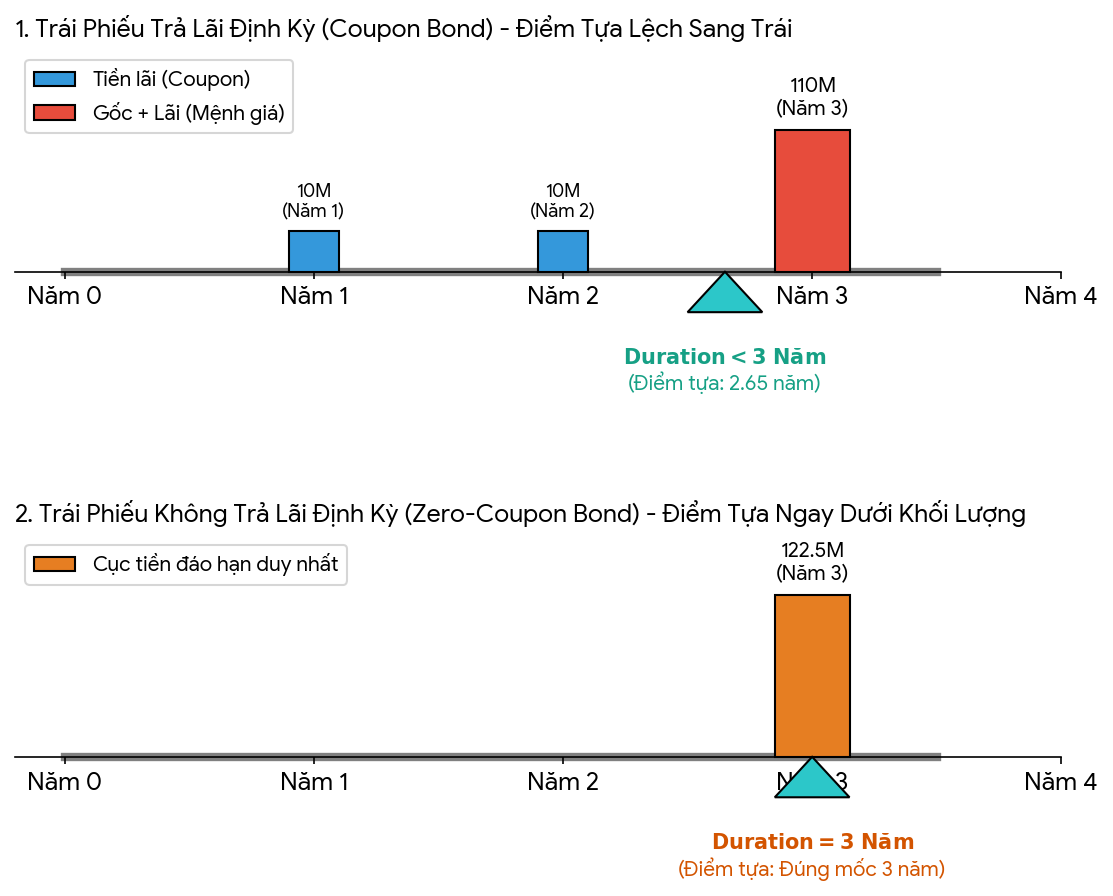

Tại sao môn Finance lại "cuồng" khái niệm Duration này?
Vì Duration là thước đo hoàn hảo nhất cho Độ nhạy cảm của giá trái phiếu trước biến động của lãi suất.
Như bạn đã nói ở câu trước, dòng tiền ở càng xa thì khi discount về càng bị lãi suất "bào mòn" mạnh do số mũ t lớn.

• Duration càng lớn (Trọng tâm dòng tiền càng xa): Trái phiếu đó càng "sợ" lãi suất. Lãi suất thị trường chỉ cần nhích lên một chút, giá trái phiếu sẽ lao dốc rất mạnh.

• Duration càng nhỏ (Trọng tâm dòng tiền gần): Trái phiếu đó rất "lỳ đòn". Lãi suất thị trường có biến động thế nào, giá của nó cũng chỉ dao động nhẹ, vì bạn đã thu hồi phần lớn giá trị từ sớm rồi.
Quy tắc ngón tay cái (Thumb Rule) trong phòng thi:

Nếu đề bài cho một trái phiếu có Duration = 5, điều đó có nghĩa là: Nếu lãi suất thị trường tăng 1%, thì giá của trái phiếu đó sẽ GIẢM khoảng 5%. (Và ngược lại, nếu lãi suất giảm 1%, giá trái phiếu sẽ TĂNG 5%).

### Duration-Price Relationship
*   Price change is proportional to duration.
*   The percentage change in bond price is the product of modified duration and the change in the bond's yield to maturity.

$$\frac{\Delta P}{P} = -D \times \frac{\Delta y}{1+y}$$

$$\frac{\Delta P}{P} = -D_M \Delta y \qquad \text{where} \qquad D_M = \frac{D}{1 + y} \qquad \text{and} \qquad D_M \quad \text{is modified duration}$$

*   Rule 1: The duration of a zero-coupon bond equals its time to maturity.

*   Rule 2: Holding maturity constant, a bond's duration is higher when the coupon rate is lower.

*   Rule 3: Holding the coupon rate constant, a bond's duration generally increases with its time to maturity.

*   Rule 4: Holding other factors constant, the duration of a coupon bond is higher when the bond's yield to maturity is lower.

*   Rule 5: The duration of a level perpetuity is equal to: $\frac{1+y}{y}$

---


------------------------------

### Phần 1: Mối quan hệ giữa Duration và Giá trái phiếu (Công thức biến động)

Hai công thức ở giữa hình bản chất là một, dùng để trả lời câu hỏi: "Nếu lãi suất thị trường thay đổi một lượng là $\Delta y$, thì giá trái phiếu sẽ tăng/giảm bao nhiêu phần trăm ($\frac{\Delta P}{P}$)?"
$$\frac{\Delta P}{P} = -D_M \times \Delta y$$

* Dấu trừ ($-$): Thể hiện mối quan hệ ngược chiều mà bạn đã biết (Lãi suất tăng $\rightarrow$ Giá giảm; Lãi suất giảm $\rightarrow$ Giá tăng).

* $D_M$ (Modified Duration - Thời lượng sửa đổi): Được tính bằng cách lấy Macaulay Duration ($D$) chia cho $(1 + y)$. Nó là thước đo chính xác mức độ nhạy cảm của giá.

* Ví dụ ứng dụng: Nếu một trái phiếu có $D_M = 4.5$ và lãi suất tăng thêm $1\%$ ($\Delta y = +1\%$), thì giá trái phiếu sẽ giảm: $-4.5 \times 1\% = -4.5\%$.

------------------------------

### Phần 2: 5 Quy luật vàng của Duration (Bản chất trực quan)
Cả 5 quy luật này đều xoay quanh một nguyên lý cốt lõi: Dòng tiền càng bị đẩy về phía tương lai xa xôi, Duration càng lớn (trọng tâm càng xa) và trái phiếu càng nhạy cảm với rủi ro.

* Rule 1 (Trái phiếu Zero-coupon): Duration đúng bằng thời gian đáo hạn. (Vì không có coupon gỡ vốn giữa chừng, toàn bộ trọng tâm nằm ở năm cuối cùng - như ví dụ bập bầy của chúng ta).
* Rule 2 (Mối quan hệ với Coupon Rate): Giữ nguyên thời gian đáo hạn, lãi suất coupon càng thấp $\rightarrow$ Duration càng cao.
* Giải thích: Lãi coupon hàng năm ít đi đồng nghĩa với việc bạn "gỡ vốn" được ít hơn ở những năm đầu. Trọng tâm dòng tiền bị đẩy về cục tiền gốc to đùng ở cuối kỳ.
* Rule 3 (Mối quan hệ với Thời gian đáo hạn): Giữ nguyên lãi coupon, thời gian đáo hạn càng dài $\rightarrow$ Duration càng lớn.
* Giải thích: Trái phiếu 30 năm rõ ràng có các dòng tiền nằm xa hơn rất nhiều so với trái phiếu 5 năm, làm trọng tâm bị kéo dãn ra xa.
* Rule 4 (Mối quan hệ với YTM): Giữ nguyên các yếu tố khác, YTM càng thấp $\rightarrow$ Duration càng cao.
* Giải thích: Hãy nhớ lại ý bạn nói về phép chiết khấu (discount). Khi YTM thấp, các dòng tiền ở xa sẽ bị bào mòn ít hơn, giữ được giá trị cao hơn khi quy về hiện tại. Do đó, chúng chiếm tỷ trọng lớn hơn trong trọng tâm dòng tiền, đẩy Duration ra xa.
* Rule 5 (Trái phiếu vô hạn - Perpetuity): Loại trái phiếu trả lãi mãi mãi, không bao giờ trả gốc. Duration của nó không phụ thuộc vào thời gian (vì làm gì có ngày đáo hạn) mà tính bằng công thức cố định: $\frac{1+y}{y}$.

------------------------------

### Bảng tóm tắt để bạn dễ "học vẹt" đi thi

| Yếu tố thay đổi (Tăng lên $\uparrow$) | Tác động tới Duration | Bản chất dòng tiền |
|---|---|---|
| Thời gian đáo hạn (Maturity) $\uparrow$ | Tăng $\uparrow$ | Dòng tiền bị kéo dài ra xa trong tương lai. |
| Lãi suất Coupon $\uparrow$ | Giảm $\downarrow$ | Nhận nhiều tiền mặt sớm hơn để gỡ vốn. |
| Lãi suất YTM $\uparrow$ | Giảm $\downarrow$ | Chiết khấu mạnh làm các dòng tiền ở xa bị teo nhỏ lại. |



## 1. Ví dụ thực tế áp dụng tính toán
Giả sử bạn là một nhà quản lý quỹ đầu tư, đang sở hữu một trái phiếu doanh nghiệp có các thông số sau:

* Giá thị trường hiện tại ($P$): 100 triệu VNĐ
* Lãi suất đáo hạn ($y$): 8%/năm
* Thời lượng Macaulay ($D$): 6.48 năm

Bất ngờ, Ngân hàng Trung ương công bố tăng lãi suất thị trường thêm 0.5% (tức là $\Delta y = +0.5\% = +0.005$). Bạn cần tính xem danh mục của mình bị thiệt hại bao nhiêu.
Bước 1: Tính Thời lượng sửa đổi (Modified Duration - $D_M$)
$$D_M = \frac{D}{1 + y} = \frac{6.48}{1 + 0.08} = \mathbf{6.0}$$
Bước 2: Tính phần trăm thay đổi của giá trái phiếu ($\frac{\Delta P}{P}$)
Áp dụng công thức từ ảnh:
$$\frac{\Delta P}{P} = -D_M \times \Delta y = -6.0 \times 0.5\% = \mathbf{-3.0\%}$$
Bước 3: Tính số tiền thiệt hại thực tế

* Giá trái phiếu sẽ giảm mất 3% của 100 triệu $\rightarrow$ giảm 3 triệu VNĐ.
* Giá trái phiếu mới sau khi lãi suất tăng sẽ là: $100 - 3 = \mathbf{97 \text{ triệu VNĐ}}$.

------------------------------
## 2. Mục đích chính để tính phần này là gì?
Trong tài chính, người ta tính toán công thức này cho 2 mục đích tối thượng sau:
## A. Đo lường và quản trị rủi ro lãi suất (Risk Management)
Lãi suất thị trường thay đổi từng giây, làm giá trái phiếu biến động liên tục. Nhờ có $D_M$, các nhà quản lý quỹ chỉ cần nhìn một con số là biết ngay mức độ "gặp nguy hiểm" của mình.

* Ví dụ: Nếu quỹ của bạn đang giữ 1.000 tỷ VNĐ trái phiếu có $D_M = 6$, bạn biết chắc chắn rằng nếu lãi suất tăng 1%, quỹ của bạn sẽ bốc hơi ngay lập tức 60 tỷ VNĐ ($6\% \times 1.000 \text{ tỷ}$). Từ đó, bạn sẽ quyết định có nên bán bớt trái phiếu dài hạn để chuyển sang loại ngắn hạn an toàn hơn hay không.

## B. Chiến lược phòng vệ danh mục (Immunization)
Đây là đỉnh cao ứng dụng của Duration trong các quỹ hưu trí hoặc bảo hiểm.

* Các quỹ này luôn có các khoản nợ phải trả trong tương lai (ví dụ: 10 năm nữa phải trả tiền lương hưu cho người dân).
* Để đảm bảo luôn có đủ tiền bất chấp lãi suất thị trường lên hay xuống, họ sẽ mua một danh mục trái phiếu sao cho Duration của danh mục trái phiếu đúng bằng Duration của nghĩa vụ nợ (10 năm).
* Khi đó, nếu lãi suất thay đổi, phần lỗ/lãi từ việc tái đầu tư coupon sẽ tự động bù trừ hoàn hảo cho phần tăng/giảm giá của trái phiếu, giúp quỹ luôn an toàn cán đích.

Để chuẩn bị tốt nhất cho môn học, bạn có muốn tôi hướng dẫn cách làm dạng bài tập "Tính Duration của một danh mục gồm nhiều trái phiếu kết hợp" thường xuất hiện trong các câu hỏi điểm cao, hay bạn muốn làm rõ thêm về chiến lược phòng vệ danh mục (Immunization)?



Cùng đi tiếp phần Duration-Price Relationship nhé An!

1. Ý tưởng chính

Price change is proportional to duration.

Duration không chỉ là một con số mô tả "kỳ hạn hiệu dụng" — nó còn là công cụ để ước lượng mức giá trái phiếu thay đổi bao nhiêu khi YTM thay đổi. Duration lớn → giá trái phiếu nhạy cảm hơn với biến động lãi suất.

2. Công thức
Slide đưa ra 2 dạng công thức, bản chất là một:

ΔP/P =−D × Δy/(1 + y)

ΔP/P =−D_MΔy "trong đó" D_M = D/(1 + y)

Giải thích:

	* ΔP/P: phần trăm thay đổi giá trái phiếu
	* Δy: phần thay đổi của YTM (ví dụ YTM tăng từ 10% lên 10.5% thì Δy = 0.005)
	* D: Macaulay Duration (công thức bạn vừa học ở phần trước)
	* D_M: Modified Duration — là Duration đã "điều chỉnh" bằng cách chia cho (1 + y)

Vì sao có dấu âm (-)? Vì giá trái phiếu và YTM luôn biến động ngược chiều nhau: lãi suất tăng → giá trái phiếu giảm, và ngược lại.

Ý nghĩa thực tế của D_M: Modified Duration cho bạn biết gần đúng % thay đổi giá trái phiếu khi YTM thay đổi 1 đơn vị (ví dụ 1% = 0.01).


Đây là một phép xấp xỉ tuyến tính (linear approximation) — chỉ chính xác khi Δy nhỏ. Nếu Δy lớn, bạn cần thêm hiệu chỉnh Convexity (phần slide sau sẽ nói tới).

3. Năm quy tắc (Rules) về Duration

Đây là phần quan trọng — các quy tắc giúp bạn dự đoán Duration sẽ cao hay thấp mà không cần tính toán chi tiết.

Rule 1: Zero-coupon bond → Duration = Maturity

Đã học ở phần trước — vì chỉ có 1 dòng tiền duy nhất, nên "thời gian trung bình" chính là thời gian đáo hạn.

Rule 2: Giữ Maturity cố định, coupon rate thấp hơn → Duration cao hơn

Giải thích: Coupon thấp nghĩa là phần lớn giá trị trái phiếu nằm ở dòng tiền cuối cùng (mệnh giá hoàn trả), nên trọng số w_t dồn nhiều về t = maturity →

Duration gần với Maturity hơn (tức Duration cao hơn). Ngược lại, coupon cao → bạn "nhận lại tiền" nhiều hơn ở các năm đầu → Duration thấp hơn.

Trường hợp đặc biệt: coupon = 0 → Duration = Maturity (Rule 1), đây là mức Duration cao nhất có thể ở một maturity cho trước.

Rule 3: Giữ coupon rate cố định, Maturity dài hơn → Duration thường tăng

Giải thích: Trực quan dễ hiểu — trái phiếu kỳ hạn dài hơn thì dòng tiền trải dài hơn, "trung bình thời gian" nhận tiền cũng xa hơn. (Từ "generally" vì có vài trường hợp đặc biệt với trái phiếu coupon rất thấp và YTM rất cao khiến quy tắc này không hoàn toàn đúng, nhưng với hầu hết trái phiếu thông thường thì đúng.)

Rule 4: Giữ các yếu tố khác cố định, YTM thấp hơn → Duration cao hơn

Giải thích: Khi YTM thấp, hệ số chiết khấu (1 + y)^t nhỏ hơn → các dòng tiền ở tương lai xa bị chiết khấu ít hơn → trọng số w_t của các dòng tiền xa tăng lên tương đối → Duration tăng.

Khi YTM cao, dòng tiền xa bị "giảm giá" mạnh, nên trọng số dồn về các dòng tiền gần hơn → Duration giảm.

Rule 5: Duration của một perpetuity (trái phiếu vĩnh viễn trả coupon đều)
D = (1 + y)/y

Giải thích: Perpetuity là trái phiếu trả coupon đều mãi mãi, không có ngày đáo hạn. Công thức này cho thấy Duration của nó chỉ phụ thuộc vào YTM, không phụ thuộc vào "maturity" (vì maturity = vô hạn).

Ví dụ nếu y = 10%, thì D = 1.1/0.1 = 11 năm.

----

Ví dụ áp dụng công thức Modified Duration
Dùng lại trái phiếu ở ví dụ trước: Face Value = 1,000 USD, coupon 10%, kỳ hạn 3 năm, YTM = 10%, ta đã tính được:

D = 2.7355" năm",

P = 1,000" USD"

Bước 1: Tính Modified Duration

D_M = D/(1 + y) = 2.7355/1.10 = 2.4868

Bước 2: Giả sử YTM tăng từ 10% lên 10.5% (Δy = 0.005)

ΔP/P =−D_M × Δy =−2.4868 × 0.005 =−0.012434 ≈−1.24%

Bước 3: Tính mức thay đổi giá tuyệt đối

ΔP ≈−0.012434 × 1,000 =−12.43" USD"

Kết luận: Khi YTM tăng 0.5%, giá trái phiếu được ước tính giảm khoảng 12.43 USD (từ 1,000 USD xuống khoảng 987.57 USD). Đây là một ước lượng tuyến tính (xấp xỉ) — giá thực tế sau khi tính lại chính xác bằng công thức PV có thể lệch đi một chút do hiệu ứng Convexity (độ cong của đường giá-lợi suất), phần mà slide sẽ giới thiệu sau.

----



In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# --- 1. Core Calculation Logic ---
def get_bond_cashflows(face_value, coupon_rate, ytm, years, freq=1):
    # Convert to decimal and period rates
    c = coupon_rate / 100
    y = ytm / 100
    period_coupon = (face_value * c) / freq
    period_ytm = y / freq
    n_periods = int(years * freq)

    times = np.arange(1, n_periods + 1) / freq
    cfs = np.full(n_periods, period_coupon)
    cfs[-1] += face_value # Add face value to last payment

    pvs = cfs / (1 + period_ytm)**np.arange(1, n_periods + 1)
    price = np.sum(pvs)
    weights = pvs / price
    weighted_times = times * weights

    macaulay_duration = np.sum(weighted_times)
    modified_duration = macaulay_duration / (1 + period_ytm)

    return {
        'times': times,
        'pvs': pvs,
        'weights': weights,
        'weighted_times': weighted_times,
        'price': price,
        'D': macaulay_duration,
        'Dm': modified_duration,
        'freq': freq,
        'years': years
    }

# --- 2. HTML Table Generation ---
def generate_html_table(data, title):
    rows_html = ""
    # Generate rows for each period
    for t, pv, w, tw in zip(data['times'], data['pvs'], data['weights'], data['weighted_times']):
        rows_html += f"""
        <tr>
            <td style="text-align: center;">{t:.1f}</td>
            <td style="text-align: right;">{pv:,.2f}</td>
            <td style="text-align: center;">{w:.4f}</td>
            <td style="text-align: center;">{tw:.4f}</td>
        </tr>
        """

    # Construct the full table with summary footer
    table_html = f"""
    <div style="flex: 1; min-width: 300px; margin: 5px; border: 1px solid #ddd; padding: 10px; border-radius: 5px;">
        <h4 style="text-align: center; margin-top: 0;">{title}</h4>
        <table style="width: 100%; border-collapse: collapse; font-family: monospace; font-size: 0.9em;">
            <thead style="background-color: #f9f9f9; border-bottom: 2px solid #aaa;">
                <tr>
                    <th style="text-align: center;">t</th>
                    <th style="text-align: right;">PV(CF)</th>
                    <th style="text-align: center;">w<sub>t</sub></th>
                    <th style="text-align: center;">t*w<sub>t</sub></th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
            <tfoot style="border-top: 2px solid #aaa; font-weight: bold;">
                <tr>
                    <td style="text-align: center;">Price</td>
                    <td style="text-align: right;">{data['price']:,.2f}</td>
                    <td style="text-align: center;">1.00</td>
                    <td></td>
                </tr>
                <tr>
                    <td colspan="2"></td>
                    <td style="text-align: center; background-color: #eef;">D</td>
                    <td style="text-align: center; background-color: #eef;">{data['D']:.4f}</td>
                </tr>
                <tr>
                    <td colspan="2"></td>
                    <td style="text-align: center; background-color: #eef;">D<sub>M</sub></td>
                    <td style="text-align: center; background-color: #eef;">{data['Dm']:.4f}</td>
                </tr>
            </tfoot>
        </table>
    </div>
    """
    return table_html

# --- 3. Interactive Handler & UI ---
output_widget = widgets.Output()
style = {'description_width': 'initial'}

face_widget = widgets.FloatText(value=10000, description='Face Value:', style=style)
coupon_widget = widgets.FloatSlider(value=12.0, min=1, max=20, step=0.5, description='Coupon (%):', style=style, continuous_update=True)
maturity_widget = widgets.IntSlider(value=5, min=2, max=15, step=1, description='Maturity (Y):', style=style, continuous_update=True)
ytm_widget = widgets.FloatSlider(value=12.0, min=1, max=20, step=0.5, description='YTM (%):', style=style, continuous_update=True)

def update_tables(face, coupon, maturity, ytm):
    # Calculate data for all three bonds
    b1 = get_bond_cashflows(face, coupon, ytm, maturity, freq=1)
    b2 = get_bond_cashflows(face, coupon, ytm, maturity, freq=2)
    b3 = get_bond_cashflows(face, coupon, ytm, maturity * 2, freq=1)

    # Generate HTML for each
    html1 = generate_html_table(b1, f"Bond 1 (Annual, {maturity}Y)")
    html2 = generate_html_table(b2, f"Bond 2 (Semi-Annual, {maturity}Y)")
    html3 = generate_html_table(b3, f"Bond 3 (Annual, {maturity*2}Y)")

    # Combine into one flexbox container
    full_html = f"""
    <div style="display: flex; flex-wrap: wrap; justify-content: center; width: 100%;">
        {html1}
        {html2}
        {html3}
    </div>
    """

    with output_widget:
        clear_output(wait=True)
        display(HTML(full_html))

# Link widgets
widgets.interactive_output(update_tables, {
    'face': face_widget,
    'coupon': coupon_widget,
    'maturity': maturity_widget,
    'ytm': ytm_widget
})

# Layout
controls = widgets.HBox([
    widgets.VBox([face_widget, coupon_widget]),
    widgets.VBox([maturity_widget, ytm_widget])
])

display(controls, output_widget)

# Initial load
update_tables(face_widget.value, coupon_widget.value, maturity_widget.value, ytm_widget.value)

Output()

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# --- 1. Core Calculation Function (with fixes) ---
def calculate_macaulay_duration(coupon_rate, ytm, maturity, face_value=1000, freq=1):
    # This function calculates the Macaulay Duration for a single bond.
    if maturity == 0:
        return 0
    if coupon_rate == 0:
        return maturity

    c = coupon_rate / 100
    y = ytm / 100

    # Guard against division by zero or near-zero yields.
    if abs(y) < 1e-9:
        y = 1e-9

    periods = maturity

    # price = (c * face_value / y) * (1 - 1/((1+y)**periods)) + face_value/((1+y)**periods)

    # Macaulay Duration formula (closed-form)
    duration = ((1 + y) / y) - ( (1 + y) + periods * (c - y) ) / ( c * ((1+y)**periods - 1) + y )
    return duration

# --- 2. Plotting Function (with fixes) ---
def generate_duration_plot(ytm, c1, c2, c3):
    fig, ax = plt.subplots(figsize=(10, 6))

    maturities = np.arange(1, 31)

    # 1. Plot the Zero-Coupon Bond
    ax.plot(maturities, maturities, color='black', label='Zero-Coupon Bond')

    # 2. Define the three bonds
    bonds = [
        {'coupon': c1, 'color': 'deepskyblue', 'style': '-'},
        {'coupon': c2, 'color': 'gray', 'style': '-'},
        {'coupon': c3, 'color': 'dodgerblue', 'style': '--'}
    ]

    # 3. Calculate and plot duration for each bond
    for bond in bonds:
        durations = [calculate_macaulay_duration(bond['coupon'], ytm, m) for m in maturities]
        ax.plot(maturities, durations, color=bond['color'], linestyle=bond['style'],
                label=f'{bond["coupon"]}% Coupon', linewidth=2.5)

    # --- Formatting with Fix 5 for clarity and the requested title format ---
    ax.set_title(f'Duration vs. Maturity (Annual Payments, Global YTM = {ytm:.2f}%)', fontsize=15)
    ax.set_xlabel('Maturity (years)', fontsize=12)
    ax.set_ylabel('Duration (years)', fontsize=12)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 30)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

    plt.show()

# --- 3. Interactive Widgets Setup (with fixes) ---
output_widget = widgets.Output()
style = {'description_width': 'initial'}

ytm_widget = widgets.FloatSlider(value=10.0, min=1, max=20, step=0.5, description='Global YTM (%):', style=style, continuous_update=True)
c1_widget = widgets.FloatSlider(value=12.0, min=0, max=20, step=0.5, description='Bond 1 Coupon (%):', style=style, continuous_update=True)
c2_widget = widgets.FloatSlider(value=8.0, min=0, max=20, step=0.5, description='Bond 2 Coupon (%):', style=style, continuous_update=True)
c3_widget = widgets.FloatSlider(value=10.0, min=0, max=20, step=0.5, description='Bond 3 Coupon (%):', style=style, continuous_update=True)

def interactive_handler(ytm, c1, c2, c3):
    with output_widget:
        clear_output(wait=True)
        generate_duration_plot(ytm, c1, c2, c3)

# Fix 1: Keep a reference to the interactive_output widget to prevent garbage collection.
_io_link = widgets.interactive_output(interactive_handler, {
    'ytm': ytm_widget,
    'c1': c1_widget,
    'c2': c2_widget,
    'c3': c3_widget
})

# Organize the UI
bond_controls = widgets.VBox([c1_widget, c2_widget, c3_widget])
ui = widgets.VBox([ytm_widget, bond_controls])

# Display the UI and the output area
display(ui, output_widget)
interactive_handler(ytm_widget.value, c1_widget.value, c2_widget.value, c3_widget.value)

Output()

---

### Interest Rate Risk

* Modified duration measures the sensitivity of a bond's price to a small change in its annual yield $y$.

$$
P = \sum_{k=1}^{mT}\frac{CF_k}{(1+y/m)^k},
\qquad D_M=-\frac{1}{P}\frac{dP}{dy},
\qquad \Delta P\approx-PD_M\Delta y
$$

Here $m$ is the number of coupon payments per year and $T$ is maturity in years.

* Money (dollar) duration is $PD_M=-dP/dy$.
    * For a portfolio, money durations add when yields move together.

* DV01 is the value of a one-basis-point yield change:
    *   $\text{DV01}\approx PD_M\times0.0001$.
    *   It is the approximate price decrease for a one-basis-point rise in yield; portfolio DV01s also add.

---



1. Mục đích của phần này
Khi bạn nắm giữ một trái phiếu, giá trái phiếu sẽ thay đổi khi lãi suất thị trường (yield - YTM) thay đổi. Phần này cung cấp công cụ để đo lường mức độ nhạy cảm đó, cụ thể là trả lời câu hỏi:

"Nếu lãi suất thay đổi một chút, giá trái phiếu của tôi sẽ thay đổi bao nhiêu?"


Đây là công cụ cực kỳ quan trọng trong quản lý rủi ro cho các quỹ đầu tư, ngân hàng, công ty bảo hiểm — những bên nắm giữ lượng lớn trái phiếu và cần biết trước thiệt hại/lợi nhuận khi lãi suất biến động.

2. Các khái niệm chính (bám sát slide)
a) Modified Duration (D_M)
P =∑_(k=1)^(mT)(CF_k)/((1 + y/m)^k), D_M =−1/PdP/dy, ΔP ≈−PD_MΔy
	* P: giá trái phiếu (tổng giá trị hiện tại của các dòng tiền CF_k)
	* m: số lần trả coupon trong 1 năm
	* T: số năm đến đáo hạn
	* D_M: Modified Duration — đo % thay đổi giá khi yield thay đổi 1 đơn vị
	* ΔP ≈−PD_MΔy: công thức ước lượng mức thay đổi giá tuyệt đối khi yield thay đổi một lượng nhỏ Δy

Ý nghĩa: Dấu trừ (−) cho biết giá và yield di chuyển ngược chiều — yield tăng thì giá giảm, và ngược lại.

b) Money (Dollar) Duration
PD_M =−dP/dy
Đây là độ nhạy giá tính bằng tiền (không phải %). Điểm quan trọng slide nhấn mạnh:

Đối với một portfolio, các money duration có thể cộng lại với nhau nếu yield của các trái phiếu di chuyển cùng nhau (parallel shift).


c) DV01 (Dollar Value of 01)
DV01 ≈ PD_M × 0.0001
	* Đây là mức giảm giá xấp xỉ khi yield tăng 1 basis point (0.01%)
	* DV01 của portfolio cũng cộng được như money duration

3. Ví dụ đơn giản để hình dung
Giả sử bạn có một trái phiếu với:

	* Giá hiện tại: P = 1,000
	* Modified Duration: D_M = 5 năm
	* Yield tăng Δy = 0.01 (tức 100 basis points = 1%)

Bước 1 — Ước lượng thay đổi giá:
ΔP ≈−PD_MΔy =−(1,000)(5)(0.01)=−50

→ Giá trái phiếu giảm khoảng 50 (từ 1,000 xuống khoảng 950) khi yield tăng 1%.

Bước 2 — Tính DV01:
DV01 ≈ PD_M × 0.0001 =(1,000)(5)(0.0001)= 0.50

→ Mỗi khi yield tăng 1 basis point (0.01%), giá trái phiếu giảm khoảng 0.50.

Kiểm tra lại: 100 basis points × 0.50 = 50 → khớp với kết quả ở Bước 1. Đúng vậy!

4. Áp dụng thực tế
	* Nếu bạn quản lý một portfolio gồm nhiều trái phiếu, bạn cộng DV01 của từng trái phiếu để biết toàn bộ portfolio sẽ mất bao nhiêu tiền nếu yield tăng 1bp.
	* Đây là cơ sở để phòng ngừa rủi ro (hedging) — ví dụ, nếu DV01 portfolio của bạn là +1,000, bạn có thể tìm một vị thế khác có DV01 = -1,000 để triệt tiêu rủi ro lãi suất.



1. Hai phần này KHÔNG phải là hai kiến thức khác nhau — mà là MỘT, chỉ khác cách trình bày
Phần "Duration-Price Relationship" (bạn vừa gửi) giới thiệu công thức:
ΔP/P =−D_MΔy, D_M = D/(1 + y)

Phần "Interest Rate Risk" (tôi vừa giảng) viết:
D_M =−1/PdP/dy, ΔP ≈−PD_MΔy

Đây chính là cùng một công thức ΔP/P ≈−D_MΔy, chỉ là:

	* Phần đầu (bạn vừa học) cho bạn công thức "có sẵn" để tính toán, dùng Macaulay Duration D rồi suy ra D_M.
	* Phần sau giải thích công thức đó đến từ đâu — bằng đạo hàm — và mở rộng sang DV01, money duration cho portfolio.

2. Tại sao lại có đạo hàm dP/dy?
Vì bản chất của "độ nhạy" chính là đạo hàm!

Nhắc lại, giá trái phiếu là một hàm số của yield:
P(y)=∑_(k=1)^(mT)(CF_k)/((1 + y/m)^k)

Khi y thay đổi một lượng rất nhỏ, giá P cũng thay đổi theo. Trong toán học, tốc độ thay đổi của một hàm số theo biến số của nó chính là đạo hàm:
dP/dy = "độ dốc của đường cong giá-yield tại điểm hiện tại"

Nếu bạn lấy đạo hàm của P(y) theo y và rút gọn, bạn sẽ ra đúng:
−1/PdP/dy = D/(1 + y) = D_M

→ Đây chính là nguồn gốc toán học của công thức Modified Duration mà bạn đã học trước đó! Macaulay Duration D không phải tự nhiên sinh ra — nó được suy ra từ đạo hàm của hàm giá trái phiếu.

3. Hình dung trực quan
Nghĩ về đường cong Price-Yield (giá trái phiếu theo yield) — nó là một đường cong lồi xuống (giống đồ thị 1/x):

	* Modified Duration D_M = độ dốc (slope) của đường cong tại điểm giá hiện tại, đã chuẩn hóa theo P.
	* ΔP ≈−PD_MΔy chính là: lấy độ dốc đó, nhân với mức thay đổi yield, để ước lượng mức thay đổi giá — đây là phép xấp xỉ tuyến tính (linear approximation) quen thuộc trong giải tích: dùng tiếp tuyến tại 1 điểm để ước lượng hàm số lân cận điểm đó.

4. Vậy phần sau bổ sung thêm gì mới?
So với phần Duration-Price Relationship, phần Interest Rate Risk mở rộng thêm:

| Khái niệm | Ý nghĩa mới |
|---|---|
| **Money Duration** ($PD_M$) | Đổi từ đo bằng % sang đo bằng **tiền thực tế** — dễ cộng dồn cho portfolio |
| **DV01** | Chuẩn hóa thêm, cho biết thiệt hại khi yield đổi **đúng 1 basis point** — đơn vị thực dụng nhất trong thị trường |
| **Portfolio aggregation** | Money Duration và DV01 có thể **cộng lại** giữa nhiều trái phiếu, trong khi $D_M$ (dạng %) thì không cộng trực tiếp được |

Tóm lại
Bạn có thể hiểu theo trình tự logic sau:

	1. Duration-Price Relationship → cho bạn công thức sẵn để tính % thay đổi giá
	2. Interest Rate Risk → giải thích bản chất toán học (đạo hàm) phía sau công thức đó, rồi mở rộng ứng dụng sang đo bằng tiền (Money Duration, DV01) để dùng cho portfolio thực tế

Bạn có muốn tôi minh họa bằng hình vẽ đường cong Price-Yield để thấy rõ "đạo hàm = độ dốc tiếp tuyến" không?

### Interest Rate Risk

A bond with a par value of €1,000, a maturity of 6 years, and semi-annual coupon payments has a price of €1,075.78 and a yield to maturity of 5.5%.

* What is the annual coupon rate?
* What is the Macaulay duration of the bond at the current price?
* What is the modified duration?
* What is the DV01 at the current yield?
* Estimate the price change given a 50-basis-point decline in the YTM.
* What is the actual price of the bond when the YTM declines to 5.0%?

---

Ý 2

Đúng rồi bạn, tư duy của bạn chuẩn xác 100%! Để tôi viết ra công thức tường minh dạng toán học "chạy bằng cơm" (không dùng phím tắt máy tính) để bạn thấy rõ từng bước dịch chuyển dòng tiền nhé.
Bản chất của Macaulay Duration ($D_{kỳ}$) là trung bình gia quyền (trọng số) của thời gian.

* Bước 1: Tính giá trị hiện tại (PV) của dòng tiền tại mỗi kỳ $t$.
* Bước 2: Tính trọng số $W_t$ bằng cách lấy PV của kỳ đó chia cho tổng giá trị trái phiếu ($P$).
* Bước 3: Lấy thời gian $t$ nhân với trọng số $W_t$ tương ứng rồi cộng tất cả lại.

------------------------------

## Công thức tổng quát "chạy bằng tay":
$$D_{kỳ} = \left( 1 \times \frac{PV_1}{P} \right) + \left( 2 \times \frac{PV_2}{P} \right) + \dots + \left( n \times \frac{PV_n}{P} \right)$$
Trong đó, công thức tính PV của dòng tiền tại kỳ $t$ bất kỳ là:
$$PV_t = \frac{\text{Dòng tiền của kỳ đó } (CF_t)}{(1+r)^t}$$

------------------------------

## Áp dụng cụ thể vào bài toán này (12 kỳ):
Nhắc lại số liệu: $P = 1,075.78$; $r = 2.75\% = 0.0275$.
Tiền lãi định kỳ từ kỳ 1 đến kỳ 11 là €35. Kỳ 12 nhận cả gốc lẫn lãi là €1,035.
Nếu viết tường minh ra để cộng bằng tay, chúng ta sẽ có 12 cụm phân số như sau:
$$D_{kỳ} = \underbrace{\left[ 1 \times \frac{\frac{35}{(1.0275)^1}}{1,075.78} \right]}_{\text{Kỳ 1}} + \underbrace{\left[ 2 \times \frac{\frac{35}{(1.0275)^2}}{1,075.78} \right]}_{\text{Kỳ 2}} + \dots + \underbrace{\left[ 11 \times \frac{\frac{35}{(1.0275)^{11}}}{1,075.78} \right]}_{\text{Kỳ 11}} + \underbrace{\left[ 12 \times \frac{\frac{1,035}{(1.0275)^{12}}}{1,075.78} \right]}_{\text{Kỳ 12 (Cuối)}}$$
------------------------------

## Rút gọn công thức toán học để viết vào bài thi:
Để không phải viết 12 cụm dài dòng trên giấy thi, các thầy cô thường gom tiền lãi coupon ($C$) và mệnh giá gốc ($M$) lại thành một công thức giải nhanh toán học như sau (đây là công thức rút gọn từ chuỗi cấp số nhân):
$$D_{kỳ} = \frac{1+r}{r} - \frac{1+r + n(c - r)}{c \times [(1+r)^n - 1] + r}$$
Trong đó:

* $r = 2.75\% = 0.0275$ (Lãi suất kỳ)
* $c = \frac{35}{1,000} = 3.5\% = 0.035$ (Lãi suất coupon tính theo kỳ)
* $n = 12$ (Tổng số kỳ)

Thay số vào công thức rút gọn này:
$$D_{kỳ} = \frac{1.0275}{0.0275} - \frac{1.0275 + 12 \times (0.035 - 0.0275)}{0.035 \times [(1.0275)^{12} - 1] + 0.0275}$$
$$D_{kỳ} = 37.3636 - 27.2906 = \mathbf{10.073 \text{ kỳ}}$$
Sau khi ra được $10.073 \text{ kỳ}$, bạn chỉ cần đổi ra năm bằng cách chia cho tần suất trả lãi $m = 2$:
$$D_{năm} = \frac{10.073}{2} = \mathbf{5.036 \text{ năm}}$$



### 📝 GIẢI CHI TIẾT BÀI TẬP: INTEREST RATE RISK (SLIDE 0790dfc6)

Dưới đây là hướng dẫn giải từng bước cực kỳ chi tiết bằng tiếng Việt để bạn hiểu rõ bản chất và tự tin làm bài thi nhé!

---

### 📌 Tóm tắt đề bài:
*   Mệnh giá ($F$): 1,000 €
*   Thời gian đáo hạn ($T$): 6 năm
*   Tần suất trả coupon ($f$): 2 lần/năm (bán niên - semi-annual) $\rightarrow$ Tổng số kỳ thanh toán $n = 6 \times 2 = 12$ kỳ.
*   Giá thị trường hiện tại ($P_0$): 1,075.78 €
*   Lợi suất đáo hạn hiện tại ($YTM$): $y = 5.5\%$/năm $\rightarrow$ Lợi suất mỗi kỳ bán niên $y/2 = 2.75\% = 0.0275$.

---

### ➡️ Bước 1: Tính lãi suất Coupon năm (Annual Coupon Rate)?
Để tìm lãi suất coupon, trước hết ta cần tìm số tiền coupon nhận được mỗi kỳ bán niên ($C$). Ta thiết lập phương trình giá trị hiện tại của trái phiếu:
$$P_0 = C \times \left[ \sum_{k=1}^{12} \frac{1}{(1 + 0.0275)^k} \right] + \frac{1,000}{(1 + 0.0275)^{12}}$$

*   **Tính PV của gốc:**
    $$\frac{1,000}{(1.0275)^{12}} \approx 722.13 \text{ €}$$
*   **Tính PV của chuỗi coupon (sử dụng công thức Annuity):**
    $$\text{Annuity Factor} = \frac{1 - (1.0275)^{-12}}{0.0275} \approx 10.1042$$

Thay các giá trị vào phương trình:
$$1,075.78 = C \times 10.1042 + 722.13$$
$$C \times 10.1042 = 1,075.78 - 722.13 = 353.65$$
$$C \approx \frac{353.65}{10.1042} \approx 35 \text{ € (mỗi kỳ bán niên)}$$

*   **Kết luận:** Coupon nhận được cả năm là $35 \times 2 = 70 \text{ €}$.
*   **Lãi suất Coupon năm (Annual Coupon Rate) là:**
    $$\frac{70}{1,000} = 7\%$$

---

### ➡️ Bước 2: Tính Macaulay Duration ($D$)?
Macaulay Duration là trung bình có trọng số của các mốc thời gian nhận tiền ($t$ tính bằng năm):
$$D = \sum_{t} t \times w_t$$
Trong đó trọng số $w_t$ là tỷ lệ giữa giá trị hiện tại của dòng tiền tại mốc $t$ chia cho tổng giá trị trái phiếu ($P_0 = 1,075.78$).

*(Bảng tính chi tiết dòng tiền PV được liệt kê ở slide đáp án phía sau)*
Sau khi nhân từng mốc thời gian $t = [0.5, 1.0, 1.5, ..., 6.0]$ với các trọng số tương ứng và cộng lại, ta được:
$$D \approx 5.0429 \text{ năm}$$

*(Ý nghĩa: Dù 6 năm mới đáo hạn hoàn toàn, nhưng vì bạn nhận coupon đều đặn 6 tháng/lần nên "thời gian hòa vốn hiệu dụng" thực tế chỉ là 5.0429 năm).*

---

### ➡️ Bước 3: Tính Modified Duration ($D_M$)?
Vì trái phiếu này trả coupon bán niên ($m=2$), công thức Modified Duration sẽ là:
$$D_M = \frac{D}{1 + \frac{y}{2}} = \frac{5.0429}{1 + 0.0275} \approx 4.9080 \text{ năm}$$

---

### ➡️ Bước 4: Tính DV01 (Dollar Value of 01)?
DV01 là số tiền trái phiếu sẽ giảm khi lợi suất đáo hạn ($YTM$) tăng lên đúng **1 basis point (0.01% = 0.0001)**:
$$\text{DV01} \approx P_0 \times D_M \times 0.0001$$
$$\text{DV01} \approx 1,075.78 \times 4.9080 \times 0.0001 \approx 0.5280 \text{ €/bp}$$

*(Ý nghĩa: Mỗi khi lãi suất thị trường tăng 1 basis point (0.01%), bạn sẽ mất khoảng 0.528 € trên mỗi trái phiếu).*

---

### ➡️ Bước 5: Ước lượng mức thay đổi giá khi YTM GIẢM 50 basis points?
Lợi suất giảm $\Delta y = -50 \text{ bps} = -0.005$ (từ 5.5% xuống 5.0%).

*   **Theo phần trăm thay đổi giá ($\frac{\Delta P}{P}$):**
    $$\frac{\Delta P}{P} \approx -D_M \times \Delta y = -4.9080 \times (-0.005) \approx +2.454\%$$
*   **Theo số tiền thay đổi tuyệt đối ($\Delta P$):**
    $$\Delta P \approx -P_0 \times D_M \times \Delta y = 1,075.78 \times 2.454\% \approx +26.40 \text{ €}$$

*(Kết luận: Khi lãi suất giảm 50 bps, giá trái phiếu được dự báo tăng thêm khoảng 26.40 €).*

---

### ➡️ Bước 6: Tính giá thực tế của trái phiếu khi YTM giảm về 5.0%?
Khi YTM mới là $5.0\%$, lãi suất chiết khấu bán niên mới là $5.0\% / 2 = 2.5\% = 0.025$.

Ta tính lại giá trị hiện tại chính xác của trái phiếu với $y_{new} = 2.5\%$:
$$P(5.0\%) = 35 \times \left[ \frac{1 - (1.025)^{-12}}{0.025} \right] + \frac{1,000}{(1.025)^{12}}$$
$$P(5.0\%) = 35 \times 10.2578 + 743.56$$
$$P(5.0\%) = 359.02 + 743.56 = 1,102.58 \text{ €}$$

*   **Mức tăng giá thực tế:** $1,102.58 - 1,075.78 = +26.80 \text{ €}$ (tương đương $+2.49\%$).
*   **So sánh với xấp xỉ ở Bước 5:** Ước lượng bằng Duration cho ra $+26.40 \text{ €}$, lệch khoảng $0.40 \text{ €}$ so với giá thực tế $+26.80 \text{ €}$. Sự chênh lệch này là do đường cong giá-lợi suất thực tế lồi lên (Convexity), chúng ta sẽ làm rõ hơn ở các slide tiếp theo nhé!

### Interest Rate Risk

$$
\begin{aligned}
1,075.78 &= C\sum_{k=1}^{12}\frac{1}{(1+2.75\%)^k}+\frac{1,000}{(1+2.75\%)^{12}} \\
&\approx 10.1042C+722.13
\end{aligned}
$$

$$
C\approx\frac{1,075.78-722.13}{10.1042}=35.00
\qquad\Rightarrow\qquad
\text{Annual coupon rate}=\frac{2\times35}{1,000}=7\%
$$

The present-value weights in the table give Macaulay duration $D=5.0429$ years. Therefore,

$$
D_M=\frac{D}{1+y/2}=\frac{5.0429}{1.0275}=4.9080\text{ years}
$$

$$
\text{DV01}\approx PD_M(0.0001)=1,075.78\times 4.9080\times0.0001=0.5280\text{ per bp}
$$

For a decline of 50 bp, $\Delta y=-0.005$:

$$
\Delta P\approx-PD_M\Delta y=+26.40
\quad\text{or}\quad
\frac{\Delta P}{P}\approx +2.454\%.
$$

At the new yield,

$$ P(5.0\%)=\sum_{k=1}^{12}\frac{35}{(1+2.50\%)^k}+\frac{1,000}{(1+2.50\%)^{12}}=1,102.58.$$

The actual price change is $+26.80$, or $+2.49\%$.

| t | PV(CF)@5.5% | w<sub>t</sub>@5.5% | t\*w<sub>t</sub>@5.5% | PV(CF)@5.0% | w<sub>t</sub>@5.0% | t\*w<sub>t</sub>@5.0% |
|---|---|---|---|---|---|---|
| 0.5 | 34.06 | 0.0317 | 0.0158 | 34.15 | 0.0310 | 0.0155 |
| 1.0 | 33.15 | 0.0308 | 0.0308 | 33.31 | 0.0302 | 0.0302 |
| 1.5 | 32.26 | 0.0300 | 0.0450 | 32.50 | 0.0295 | 0.0442 |
| 2.0 | 31.40 | 0.0292 | 0.0584 | 31.71 | 0.0288 | 0.0575 |
| 2.5 | 30.56 | 0.0284 | 0.0710 | 30.93 | 0.0281 | 0.0701 |
| 3.0 | 29.74 | 0.0276 | 0.0829 | 30.18 | 0.0274 | 0.0821 |
| 3.5 | 28.95 | 0.0269 | 0.0942 | 29.44 | 0.0267 | 0.0935 |
| 4.0 | 28.17 | 0.0262 | 0.1047 | 28.73 | 0.0261 | 0.1042 |
| 4.5 | 27.42 | 0.0255 | 0.1147 | 28.03 | 0.0254 | 0.1144 |
| 5.0 | 26.68 | 0.0248 | 0.1240 | 27.34 | 0.0248 | 0.1240 |
| 5.5 | 25.97 | 0.0241 | 0.1328 | 26.68 | 0.0242 | 0.1331 |
| 6.0 | 747.41 | 0.6948 | 4.1686 | 769.58 | 0.6980 | 4.1879 |
| Totals: | 1,075.78 | 1.0000 | 5.0429 | 1,102.58 | 1.0000 | 5.0567 |

---

### Interest Rate Risk: Convexity

* Modified duration gives a straight-line approximation to the price change for a small change in annual YTM.
* Convexity measures the curvature of the price-yield relationship. For an option-free bond with positive convexity, the actual price is above the duration-only estimate for both a yield rise and a yield fall.

Let $Y$ be annual YTM, $f$ the number of payments per year, and $k$ the payment period. With $CF_k$ including principal in the last period,

$$
P(Y)=\sum_{k=1}^{fT}\frac{CF_k}{(1+Y/f)^k}
$$

$$
\text{Annual convexity}
=\frac{1}{P f^2(1+Y/f)^2}
\sum_{k=1}^{fT}k(k+1)\frac{CF_k}{(1+Y/f)^k}
$$

$$
\frac{\Delta P}{P}\approx-D_M\Delta Y
+\frac{1}{2}\text{Annual convexity}(\Delta Y)^2
$$

---

### Interest Rate Risk: Convexity

Consider a 5-year bond with a par value of €1,000, semi-annual coupons, an annual coupon rate of 6%, and a current YTM of 6.5%.

* What are its current price, Macaulay duration, and modified duration?
* What is its annual convexity?
* If YTM falls by 100 basis points to 5.5%, estimate the price change using (a) duration alone and (b) duration plus convexity. What is the actual new price?
* Repeat for a 100-basis-point rise in YTM to 7.5%.

---

### Interest Rate Risk: Convexity — Solution

The semi-annual coupon is €30. Amounts in the calculations below are in euros, and intermediate values are unrounded.

$$
P(Y)=\sum_{k=1}^{10}\frac{30}{(1+Y/2)^k}+\frac{1000}{(1+Y/2)^{10}},
\qquad P_0=P(0.065)=978.94
$$

The present-value-weighted cash-flow times give

$$
D=\frac{4292.9306}{978.9440}=4.3853\text{ years},
\qquad D_M=\frac{D}{1.0325}=4.2472\text{ years}
$$

Using the annual-YTM convention from the previous slide,

$$
\text{Annual convexity}
=\frac{90215.6396}{4(978.9440)(1.0325)^2}=21.6114
$$

For either yield move, use $\Delta P/P_0\approx-D_M\Delta Y+\tfrac12(21.6114)(\Delta Y)^2$. Repricing with $P(Y)$ gives the actual result.

| New YTM | $\Delta Y$ | Duration-only $\Delta P$ | Duration + convexity $\Delta P$ | Actual price | Actual $\Delta P$ |
|---|---:|---:|---:|---:|---:|
| 5.5% | −0.01 | +41.58 | +42.64 | 1,021.60 | +42.66 |
| 7.5% | +0.01 | −41.58 | −40.52 | 938.40 | −40.54 |

The convexity adjustment reduces the price-change error from about €1.08 to €0.02 for the yield fall, and from about €1.04 to €0.02 for the yield rise.

---

### Interest Rate Risk: Convexity

Convexity can also be estimated from three prices around the current annual YTM $Y$:

$$
C_{\mathrm{FD}}\approx
\frac{P(Y-h)+P(Y+h)-2P(Y)}{P(Y)h^2},
\qquad h=\text{change in annual YTM}
$$

Consider a 7-year bond with a par value of €10,000, semi-annual coupons, an annual coupon rate of 5%, and a current YTM of 5%. Find its prices at YTMs of 4%, 5%, and 6%, then estimate its annual convexity.

The semi-annual coupon is €250. All prices below are in euros.

$$
P(Y)=\sum_{k=1}^{14}\frac{250}{(1+Y/2)^k}
+\frac{10000}{(1+Y/2)^{14}}
$$

$$
P(0.04)=10605.31,\qquad P(0.05)=10000.00,\qquad P(0.06)=9435.20
$$

A 1-percentage-point move in annual YTM means $h=0.01$, even though coupons are paid semi-annually. Using the displayed prices,

$$
C_{\mathrm{FD}}\approx
\frac{10605.31+9435.20-2(10000.00)}{10000.00(0.01)^2}
=40.51
$$

---

### Interest Rate Risk: Convexity

* **Higher Convexity** $\rightarrow$ Bigger price increases when yields fall than the price declines when yields rise.

* The more **volatile interest rates**, the more attractive this asymmetry.

* Bonds with greater **convexity** $\rightarrow$ higher prices and/or lower yields, all else equal.

---

### Interest Rate Risk: Price-Yield Curve for a Callable Bond

<img src="https://github.com/HoTruongAnBBA2024/Investments_WS2026/blob/main/images/slide_3/pic_7.png?raw=1">

*   As rates fall, a call becomes more likely and limits further price gains. The bond can still trade above the call price before the call date.
*   This creates a region of negative convexity.

---



### Passive Management
*   Two passive bond portfolio strategies:
    *   Indexing
        *   Attempts to replicate the performance of a given bond index.
    *   Immunization
        *   Used widely by financial institutions such as insurance companies and pension funds to shield overall financial status from exposure to interest rate fluctuations.
*   Differ greatly in terms of risk
    *   A bond-index portfolio will have the similar risk-reward profile as the bond market index to which it is tied.
    *   Immunization strategies reduce the effect of small, parallel yield changes on a funded liability.
        *   Duration matching is approximate and requires rebalancing over time.

---



### Passive Management: Indexing

*   The idea is to create a portfolio that mirrors the composition of an index that measures the broad market.
    *   Broad market indexes
        *   Government, Agencies, Supras
        *   Corporate
        *   Mortgage-backed securities
        *   Yankee bonds
*   Challenges in constructing an indexed bond portfolio
    *   Indexes include thousands of securities
    *   Many bonds are very thinly traded
    *   Rebalancing problems
        *   Bonds are continually dropped from the index as they approach maturity.
        *   New bonds are added to the index as they are issued.
    *   Bonds generate considerable interest income that must be reinvested.

---



### Passive Management: Immunization
*   Control interest rate risk
*   Widely used by pension funds, insurance companies, and banks
*   A natural mismatch between asset and liability maturity structures.
    *   Bank liabilities are primarily the deposits owed to customers, most of which are short-term and, consequently, have low duration.
    *   Bank assets by contrast are composed largely of outstanding commercial and consumer loans or mortgages, which have longer duration.
    *   What happens when interest rates rise unexpectedly?
    *   What about the risks pension funds are exposed to?
*   The interest rate exposure of assets and liabilities is matched in the portfolio.
    *   Match the duration of the assets and liabilities.
    *   Price risk and reinvestment rate risk approximately offset near the matching point.
        *   With equal present values and matched dollar durations, assets approximately fund the liability after a small, parallel yield shift.
    *   Asset and liability values do not stay matched for every yield movement.
    *   Rebalancing is needed as time passes and yields change.

---



### Passive Management: Immunization

*   Duration matching balances the difference between the accumulated value of the coupon payments (reinvestment rate risk) and the sale value of the bond (price risk).
    *   When interest rates fall, the coupons grow less than in the base case, but the higher value of the bond offsets this.
    *   When interest rates rise, the value of the bond falls, but the coupons approximately offset it because they are reinvested at the higher rate.

*   Coupon paying bond and single-payment obligation.
    *   For a small, parallel yield shift, equally funded assets and liabilities with matched durations change in value by approximately the same amount.
    *   For greater changes in the interest rate, the present value curves diverge.
    *   Convexity
    *   Rebalancing
        *   Interest rate changes cause mismatch.
        *   Asset durations will change with time.
        *   Without rebalancing, durations will become unmatched.

---

### Passive Management: Cash Flow Matching and Dedication

* Cash-flow matching constructs a bond portfolio whose cash flows equal the liability payments on the same dates.
    * A single known liability can be matched with a zero-coupon bond having the same maturity and payoff.
* Dedication extends cash-flow matching to a series of liabilities using zero-coupon and/or coupon bonds.
* An exact match removes interest-rate risk from funding those liabilities and requires no rebalancing for rate changes.
* The match can fail if promised bond payments are not made, embedded options alter cash flows, or the liabilities change.
* Exact matching may be difficult or costly when suitable bonds are unavailable or illiquid.

---

### Question 3.1

A pension fund must meet a single known liability in 7.5 years. Assume the bonds are default-free, noncallable, and denominated in the same currency as the liability. Compare these strategies:

1. Buy a zero-coupon bond maturing in 7.5 years with a payoff equal to the liability.
2. Build a coupon-bond portfolio whose present value equals the liability's present value and whose Macaulay duration is 7.5 years.

How do the strategies differ in reinvestment risk and the need for rebalancing?

---

### Question 3.2

What does positive convexity mean for an investor in an option-free bond?

---

### Question 3.3

A 4-year bond with a par value of €1,000 pays a 5.5% annual coupon semi-annually. Its current YTM is 7%.

* Calculate its price, Macaulay duration, modified duration, and annual convexity.
* If YTM rises by 75 basis points to 7.75%, estimate the new price using:
    1. modified duration;
    2. modified duration and convexity.
* Reprice the bond at 7.75% and compare the two estimates with the actual price.

---

### Question 3.4

A 10-year bond with a par value of €1,000 pays a 4.5% annual coupon once per year. Its current YTM is 6.5%, modified duration is 7.6102 years, and annual convexity is 72.9689 years². YTM falls by 100 basis points to 5.5%.

* Calculate the initial price and the actual price at the new YTM.
* Estimate the new price using modified duration only.
* Estimate the new price using modified duration and convexity.
* Calculate the absolute pricing error of each estimate. Which is more accurate?

---

### Question 3.5

A 15-year zero-coupon bond has a face value of €1,000, a YTM of 7%, and annual compounding. Its YTM falls by 150 basis points to 5.5%.

* Calculate the initial price, modified duration, and annual convexity.
* Estimate the percentage price change and new price using modified duration only.
* Repeat using modified duration and convexity.
* Calculate the actual new price and percentage change. Which estimate is more accurate?

---

### Question 3.6

A 6-year bond with a par value of €1,000 pays a 4% annual coupon semi-annually. Its current YTM is 5.5%.

* Calculate the bond prices at YTMs of 5.0%, 5.5%, and 6.0%.
* Use these prices to estimate annual convexity with a 50-basis-point change in YTM.

---

### Question 3.7

A pension fund must pay a €1,000,000 liability exactly 6 years from today. The yield curve is flat at 5% with annual compounding. The fund can invest in default-free zero-coupon bonds maturing in 4 and 10 years. Assume yield-curve changes are parallel.

* Calculate the current present value of the liability.
* Determine the current amount invested in each bond so that the asset portfolio has the same present value and Macaulay duration as the liability.
* Calculate the face value purchased of each bond.
* Immediately after a parallel yield increase to 6%, compare the asset value with the liability's present value. Is the position still fully funded?

---

### What is next?
*   Portfolio Theory and Practice I
    *   Risk, Return, and the Historical Record
    *   Capital Allocation to Risky Assets
        *   Readings: Ch. 5 & 6
    *   Suggested Problems
        *   Ch. 16: 4, 5, 9, 11, 12, 16, 21, 23
        *   Ch 16 – CFA Problems: 7, 12

---
